# Validation DtN sur le cylindre fini — comparaison avec la solution de référence

**Projet de Recherche — 2A IM, Mines Nancy**
*Massaro Elias — Encadrant : M. Dos Santos Ferreira*

Ce notebook vérifie la formule matricielle du DtN des ondes sur le cylindre
en superposant sur un même graphique :

- la **solution de référence** obtenue par différences finies haute résolution
  sur l'EDP 1D axiale (pour un $f$ connu) ;
- la **formule spectrale (11)** obtenue par décomposition de Mittag-Leffler du
  symbole matriciel.

## Rappel du problème

Le cylindre creux $\Omega = S^1_R \times (0, L)$ a deux bords : $\Gamma_0 = \{z=0\}$
et $\Gamma_L = \{z=L\}$. L'équation des ondes

$$\partial_t^2 u - \Delta_\Omega u = 0, \qquad
\Delta_\Omega = \frac{1}{R^2}\partial_\theta^2 + \partial_z^2,$$

est munie de deux conditions de Dirichlet :
$u(\theta, 0, t) = f_0(\theta, t)$, $u(\theta, L, t) = f_L(\theta, t)$.

L'opérateur DtN est **matriciel** :

$$\Lambda\!\begin{pmatrix}f_0 \\ f_L\end{pmatrix} =
\begin{pmatrix}-\partial_z u\big|_{z=0} \\ +\partial_z u\big|_{z=L}\end{pmatrix}$$

## Formule (11) à valider

Après Fourier angulaire (mode $m$) et Laplace temporel, avec
$\mu_m(s) = \sqrt{s^2 + (m/R)^2}$ :

$$\widehat{\Lambda}_m(s) =
\begin{pmatrix} \mu_m \coth(\mu_m L) & -\mu_m/\sinh(\mu_m L) \\
-\mu_m/\sinh(\mu_m L) & \mu_m \coth(\mu_m L) \end{pmatrix}$$

Par décomposition de Mittag-Leffler (avec $\alpha = (m/R)^2$ et
$\omega_{m,k}^2 = (k\pi/L)^2 + \alpha$) :

$$\mu_m \coth(\mu_m L) = \frac{1}{L} + \frac{2}{L}\sum_{k=1}^\infty \frac{s^2 + \alpha}{s^2 + \omega_{m,k}^2}, \qquad
\frac{\mu_m}{\sinh(\mu_m L)} = \frac{1}{L} + \frac{2}{L}\sum_{k=1}^\infty \frac{(-1)^k (s^2 + \alpha)}{s^2 + \omega_{m,k}^2}$$

Par transfert de dérivée (utilisant $f(0)=f'(0)=0 \Rightarrow s^2\hat f = \mathcal L\{f''\}$),
on obtient l'expression temporelle :

$$[N f](t) = \frac{f(t)}{L} + \frac{2}{L}\sum_k \int_0^t \frac{\sin(\omega_{m,k}(t-\tau))}{\omega_{m,k}} \big[f''(\tau) + \alpha f(\tau)\big]\, d\tau$$

$$[D f](t) = \frac{f(t)}{L} + \frac{2}{L}\sum_k (-1)^k \int_0^t \frac{\sin(\omega_{m,k}(t-\tau))}{\omega_{m,k}} \big[f''(\tau) + \alpha f(\tau)\big]\, d\tau$$

et le flux DtN s'écrit :

$$[\Lambda]_0 = N \!\ast\! f_0 - D \!\ast\! f_L, \qquad
[\Lambda]_L = -D \!\ast\! f_0 + N \!\ast\! f_L$$


In [1]:
# =============================================================================
#  Imports et configuration de l'environnement
# =============================================================================

import numpy as np                 # calcul vectoriel/matriciel (tableaux, algèbre linéaire)
import matplotlib.pyplot as plt    # tracé des courbes de validation

# Affiche les figures directement dans le notebook (et non dans une fenêtre séparée).
%matplotlib inline

# Résolution des figures (points par pouce) : 110 dpi -> rendu net et lisible
# tout en gardant des fichiers raisonnablement légers.
plt.rcParams['figure.dpi'] = 110


## 1 — Solution de référence (différences finies haute résolution)

Pour un $f$ connu et un mode $m$ fixé, on résout numériquement l'EDP 1D axiale :

$$\partial_t^2 u_m - \partial_z^2 u_m + \left(\frac{m}{R}\right)^2 u_m = 0, \quad z \in (0, L)$$

avec les conditions $u_m(0, t) = f_{0,m}(t)$ et $u_m(L, t) = f_{L,m}(t)$ et
CI nulles. On utilise un schéma centré classique (ordre 2 en espace et
en temps), et on calcule les flux sortants par différences décentrées d'ordre 2.

Avec $N_z = 1000$ points et une grille temporelle fine, cette solution atteint
une précision de l'ordre de $10^{-4}$ ou mieux — elle sert de **référence
quasi-exacte** pour la formule (11).


In [2]:
def solve_wave_cylinder_mode(m, R, L, f0, fL, T, Nz=1000, CFL=0.4):
    """
    Résout pour un mode m :
        ∂_t² u - ∂_z² u + (m/R)² u = 0,   z ∈ (0, L)
        u(0, t) = f_0(t), u(L, t) = f_L(t),  CI nulles

    Retourne (t_array, flux_0, flux_L) avec
        flux_0[i] = -∂_z u(z=0, t_i)
        flux_L[i] = +∂_z u(z=L, t_i)

    C'est la SOLUTION DE RÉFÉRENCE : on discrétise directement l'EDP 1D
    axiale (équation de Klein-Gordon) par un schéma aux différences finies
    centré d'ordre 2, à haute résolution, pour servir d'étalon à la
    formule spectrale (11).
    """
    # --- Discrétisation spatiale -------------------------------------------
    dz = L / Nz                 # pas d'espace : L découpé en Nz intervalles

    # --- Discrétisation temporelle -----------------------------------------
    # Condition CFL : dt proportionnel à dz pour garantir la stabilité du
    # schéma explicite (CFL = 0.4 < 1, marge de sécurité confortable).
    dt = CFL * dz
    Nt = int(np.ceil(T / dt))   # nombre de pas pour couvrir [0, T]
    dt = T / Nt                 # on rectifie dt pour tomber exactement sur T

    # Terme de masse de l'équation de Klein-Gordon : (m/R)² (= alpha).
    mass_sq = (m / R) ** 2

    # --- Buffers pour le schéma à trois niveaux temporels ------------------
    # Le schéma centré en temps relie u^{n-1}, u^n et u^{n+1}.
    u_prev = np.zeros(Nz + 1)   # u au pas de temps n-1
    u_curr = np.zeros(Nz + 1)   # u au pas de temps n   (Nz+1 noeuds : indices 0..Nz)
    u_next = np.zeros(Nz + 1)   # u au pas de temps n+1

    # Grille temporelle et tableaux de sortie pour les flux aux deux bords.
    t_array = np.linspace(0, T, Nt + 1)
    flux_0 = np.zeros(Nt + 1)   # flux sortant en z = 0
    flux_L = np.zeros(Nt + 1)   # flux sortant en z = L

    # --- Boucle d'avancement en temps --------------------------------------
    for step in range(Nt):
        t_new = (step + 1) * dt          # instant t^{n+1} que l'on calcule

        # Conditions de Dirichlet imposées à l'instant courant t^n :
        u_curr[0]  = f0(step * dt)       # bord z = 0
        u_curr[-1] = fL(step * dt)       # bord z = L

        # Laplacien discret d'ordre 2 (schéma centré à 3 points) sur les
        # noeuds intérieurs uniquement (indices 1 .. Nz-1).
        d2z = (u_curr[2:] - 2*u_curr[1:-1] + u_curr[:-2]) / dz**2

        # Opérateur spatial complet : ∂_z² u - (m/R)² u
        L_m = d2z - mass_sq * u_curr[1:-1]

        # Schéma "saute-mouton" (leapfrog) en temps, ordre 2 :
        #   u^{n+1} = 2 u^n - u^{n-1} + dt² · (∂_z² u - α u)
        u_next[1:-1] = 2*u_curr[1:-1] - u_prev[1:-1] + dt**2 * L_m

        # Conditions de bord au nouvel instant t^{n+1}.
        u_next[0]  = f0(t_new)
        u_next[-1] = fL(t_new)

        # --- Flux sortants : dérivée normale décentrée d'ordre 2 -----------
        # En z=0, schéma décentré "avant" sur 3 points :
        #   u'(0) ≈ (-3 u_0 + 4 u_1 - u_2) / (2 dz)
        d_plus  = (-3*u_next[0]  + 4*u_next[1]  - u_next[2])  / (2 * dz)
        # En z=L, schéma décentré "arrière" symétrique :
        #   u'(L) ≈ ( 3 u_N - 4 u_{N-1} + u_{N-2}) / (2 dz)
        d_minus = ( 3*u_next[-1] - 4*u_next[-2] + u_next[-3]) / (2 * dz)

        # Conventions de signe du DtN :
        #   flux_0 = -∂_z u|_{z=0}  (normale sortante orientée vers -z)
        #   flux_L = +∂_z u|_{z=L}  (normale sortante orientée vers +z)
        flux_0[step + 1] = -d_plus
        flux_L[step + 1] = +d_minus

        # Rotation des buffers : on recycle u_prev pour le prochain u_next
        # (évite toute réallocation mémoire dans la boucle).
        u_prev, u_curr, u_next = u_curr, u_next, u_prev

    return t_array, flux_0, flux_L


## 2 — Évaluation de la formule (11)

On implémente le calcul matriciel à partir de la décomposition de Mittag-Leffler,
en utilisant la quadrature trapèze sur la grille temporelle.


In [3]:
def dtn_spectral_cylinder_mode(m, R, L, t_array,
                               f0_vals, fL_vals, f0_dd_vals, fL_dd_vals,
                               k_modes=100):
    """Évalue les deux composantes ([Λ]_0, [Λ]_L) via la formule (11).

    Met en oeuvre la décomposition de Mittag-Leffler : chaque flux est une
    somme tronquée (k = 1 .. k_modes) de convolutions temporelles
    dont le noyau est sin(ω_{m,k}·(t-τ)) / ω_{m,k}.
    Les convolutions sont approchées par quadrature trapèze.
    """
    Nt = len(t_array)
    dt = t_array[1] - t_array[0]      # pas de temps (grille supposée régulière)
    alpha = (m / R) ** 2             # terme de masse α = (m/R)²

    # --- Fréquences propres ω_{m,k}² = (kπ/L)² + α -------------------------
    ks = np.arange(1, k_modes + 1)                       # indices axiaux k = 1..k_modes
    omegas = np.sqrt((ks * np.pi / L)**2 + alpha)        # pulsations associées

    # --- Matrice des écarts de temps (t - τ) ------------------------------
    # T_diff[i, j] = t_i - t_j ; le noyau de convolution ne dépend que de
    # cette différence (système causal -> partie t - τ >= 0 seulement).
    T_diff = t_array[:, None] - t_array[None, :]
    mask = T_diff >= 0               # masque de causalité (triangle inférieur)

    # --- Poids de la quadrature trapèze, ligne par ligne ------------------
    # W[i, :] contient les poids trapèze pour intégrer de τ=0 à τ=t_i :
    #   extrémités pondérées dt/2, points intérieurs pondérés dt.
    W = np.zeros((Nt, Nt))
    for i in range(1, Nt):
        W[i, 0]  = dt / 2                       # poids du premier point
        if i > 1: W[i, 1:i] = dt                # poids des points intérieurs
        W[i, i]  = dt / 2                       # poids du dernier point (τ = t_i)

    # Conversion défensive en tableaux flottants (au cas où on passe des listes).
    f0    = np.asarray(f0_vals, dtype=float)
    fL    = np.asarray(fL_vals, dtype=float)
    f0_dd = np.asarray(f0_dd_vals, dtype=float)
    fL_dd = np.asarray(fL_dd_vals, dtype=float)

    # Source convoluée g(τ) = f''(τ) + α f(τ), issue du transfert de dérivée
    # (s² f̂ correspond à L{f''} car f(0)=f'(0)=0).
    g0 = f0_dd + alpha * f0
    gL = fL_dd + alpha * fL

    # --- Termes constants 1/L (terme k=0 de la décomposition) -------------
    # N et D partagent le même terme constant ; ils ne diffèrent que par le
    # signe (-1)^k des termes de la série.
    N_f0 = f0 / L; N_fL = fL / L
    D_f0 = f0 / L; D_fL = fL / L

    # --- Somme spectrale sur les modes axiaux k ---------------------------
    for k, omega in zip(ks, omegas):
        sign = (-1) ** k                                  # signe alterné du noyau D

        # Noyau de convolution sin(ω (t-τ))/ω, annulé là où t < τ (causalité).
        K = np.where(mask, np.sin(omega * T_diff) / omega, 0.0)

        # Multiplication terme à terme par les poids trapèze : M réalise
        # l'opérateur de convolution discret (produit matrice-vecteur).
        M = W * K

        # Convolution = produit matrice·vecteur : (M @ g)[i] ≈ ∫_0^{t_i} K g dτ
        conv_0 = M @ g0
        conv_L = M @ gL

        # Accumulation dans les noyaux N (signe +) et D (signe alterné).
        N_f0 += (2.0 / L) * conv_0
        N_fL += (2.0 / L) * conv_L
        D_f0 += (2.0 / L) * sign * conv_0
        D_fL += (2.0 / L) * sign * conv_L

    # --- Assemblage matriciel du flux DtN ---------------------------------
    #   [Λ]_0 =  N * f_0 - D * f_L
    #   [Λ]_L = -D * f_0 + N * f_L
    # (structure 2x2 du symbole : diagonale N, hors-diagonale -D)
    lambda_0 = N_f0 - D_fL
    lambda_L = -D_f0 + N_fL
    return lambda_0, lambda_L


## 3 — Choix de la donnée $f$ et tracé des courbes

On prend deux données différentes sur les deux bords (profils temporels
distincts) pour activer non trivialement tous les termes du symbole matriciel :

$$f_0(t) = t^2 e^{-t/2}\sin(2.5\, t), \qquad
f_L(t) = t^2 e^{-0.3\, t}\sin(3.7\, t).$$

Les deux satisfont bien $f(0) = f'(0) = 0$. Leurs dérivées secondes se
calculent analytiquement.


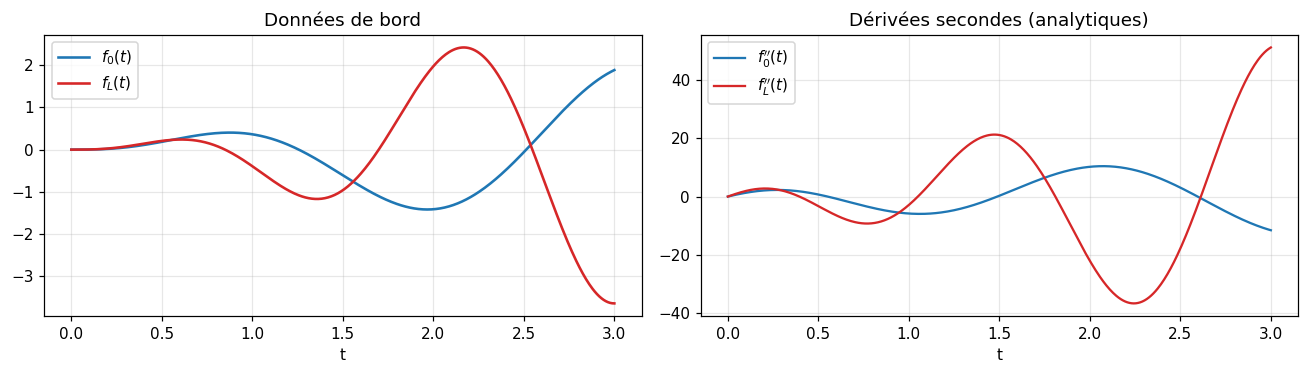

In [4]:
def make_test_data(a, w):
    """Renvoie (f, f_second) pour f(t) = t² exp(-a t) sin(w t).

    f et f'' sont fournies sous forme analytique fermée : aucune erreur
    de différentiation numérique ne vient polluer la validation.
    Le facteur t² garantit f(0) = f'(0) = 0, hypothèse indispensable
    au transfert de dérivée de la formule (11).
    """
    def g(t):
        # Évaluation vectorisée de f(t).
        t = np.asarray(t, dtype=float)
        return t**2 * np.exp(-a*t) * np.sin(w*t)

    def g_dd(t):
        # Dérivée seconde analytique de f, obtenue à la main puis factorisée
        # en partie "en sinus" et partie "en cosinus" pour limiter les calculs.
        t = np.asarray(t, dtype=float)
        E = np.exp(-a*t); S = np.sin(w*t); C = np.cos(w*t)
        # Coefficient devant sin(w t) dans f''(t).
        bracket_S = -a * (2*t - a*t**2) + (2 - 2*a*t - w**2*t**2)
        # Coefficient devant cos(w t) dans f''(t).
        bracket_C = -a * w * t**2 + w * (2*t - a*t**2) + 2 * w * t
        return E * (bracket_S * S + bracket_C * C)

    return g, g_dd


# --- Paramètres géométriques et temporels du problème ---------------------
R = 1.0     # rayon du cylindre
L = 1.5     # longueur (hauteur) du cylindre
T = 3.0     # horizon temporel de simulation

# --- Deux données de bord DISTINCTES --------------------------------------
# Profils temporels différents en z=0 et z=L : indispensable pour activer
# non trivialement tous les termes (diagonaux ET hors-diagonaux) du symbole.
f0, f0_dd = make_test_data(a=0.5, w=2.5)   # donnée du bord z = 0
fL, fL_dd = make_test_data(a=0.3, w=3.7)   # donnée du bord z = L

# --- Aperçu visuel des données et de leurs dérivées secondes --------------
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
t_show = np.linspace(0, T, 500)            # grille fine pour un tracé lisse

# Panneau gauche : les deux données de bord f_0(t) et f_L(t).
axes[0].plot(t_show, f0(t_show), 'C0-', lw=1.7, label='$f_0(t)$')
axes[0].plot(t_show, fL(t_show), 'C3-', lw=1.7, label='$f_L(t)$')
axes[0].set_title("Données de bord")
axes[0].set_xlabel('t'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Panneau droit : les dérivées secondes analytiques (entrées de la source g).
axes[1].plot(t_show, f0_dd(t_show), 'C0-', lw=1.5, label=r"$f_0''(t)$")
axes[1].plot(t_show, fL_dd(t_show), 'C3-', lw=1.5, label=r"$f_L''(t)$")
axes[1].set_title("Dérivées secondes (analytiques)")
axes[1].set_xlabel('t'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()   # évite le chevauchement des sous-figures
plt.show()


## 4 — Comparaison superposée pour plusieurs modes

On trace sur un **même graphique** la solution de référence (FD haute
résolution) et la formule (11), pour chacun des deux bords et pour
plusieurs modes azimutaux $m$.


In [5]:
def run_and_compare(m, R=R, L=L, T=T, Nz=1000, k_modes=100, CFL=0.4,
                    target_Nt=250):
    """Calcule, pour un mode m, le flux DtN par les DEUX méthodes
    (référence FD et formule spectrale 11) sur une grille temporelle commune,
    et renvoie le tout dans un dictionnaire pour comparaison ultérieure.
    """
    # --- (1) Solution de référence FD haute résolution --------------------
    t_fd, flux0_fd, fluxL_fd = solve_wave_cylinder_mode(
        m, R, L, f0, fL, T=T, Nz=Nz, CFL=CFL)

    # --- Sous-échantillonnage ---------------------------------------------
    # La formule spectrale a un coût O(Nt²) (matrices Nt×Nt). On réduit donc
    # la grille FD (très fine) à ~target_Nt points en gardant 1 point sur "step".
    step = max(1, len(t_fd) // target_Nt)
    t_sub = t_fd[::step]
    flux0_fd_sub = flux0_fd[::step]
    fluxL_fd_sub = fluxL_fd[::step]

    # --- (2) Formule spectrale (11) sur la grille sous-échantillonnée -----
    # On évalue f et f'' analytiquement aux instants de la grille réduite.
    f0_vals   = f0(t_sub);    fL_vals   = fL(t_sub)
    f0_dd_v   = f0_dd(t_sub); fL_dd_v   = fL_dd(t_sub)

    flux0_spec, fluxL_spec = dtn_spectral_cylinder_mode(
        m, R, L, t_sub, f0_vals, fL_vals, f0_dd_v, fL_dd_v,
        k_modes=k_modes)

    # Regroupement des résultats des deux méthodes pour ce mode.
    return {
        'm': m, 't': t_sub,
        'flux0_ref': flux0_fd_sub, 'flux0_spec': flux0_spec,
        'fluxL_ref': fluxL_fd_sub, 'fluxL_spec': fluxL_spec,
    }


# --- Lancement de la comparaison pour une batterie de modes azimutaux ----
# Du mode fondamental (m=0) à un mode élevé (m=100) pour sonder la robustesse.
modes = [0, 1, 2, 3,10,40,100]
results = []
for m in modes:
    print(f"Mode m = {m}...")          # suivi de progression (calcul un peu long)
    results.append(run_and_compare(m))
print("Terminé.")


Mode m = 0...


Mode m = 1...


Mode m = 2...


Mode m = 3...


Mode m = 10...


Mode m = 40...


Mode m = 100...


Terminé.


### Tracé principal : superposition sur le même graphique

Pour chaque mode, **deux courbes** sur chaque panneau :
- trait bleu continu : solution de référence (différences finies haute résolution)
- trait rouge pointillé : formule (11) spectrale

Les deux doivent coïncider.


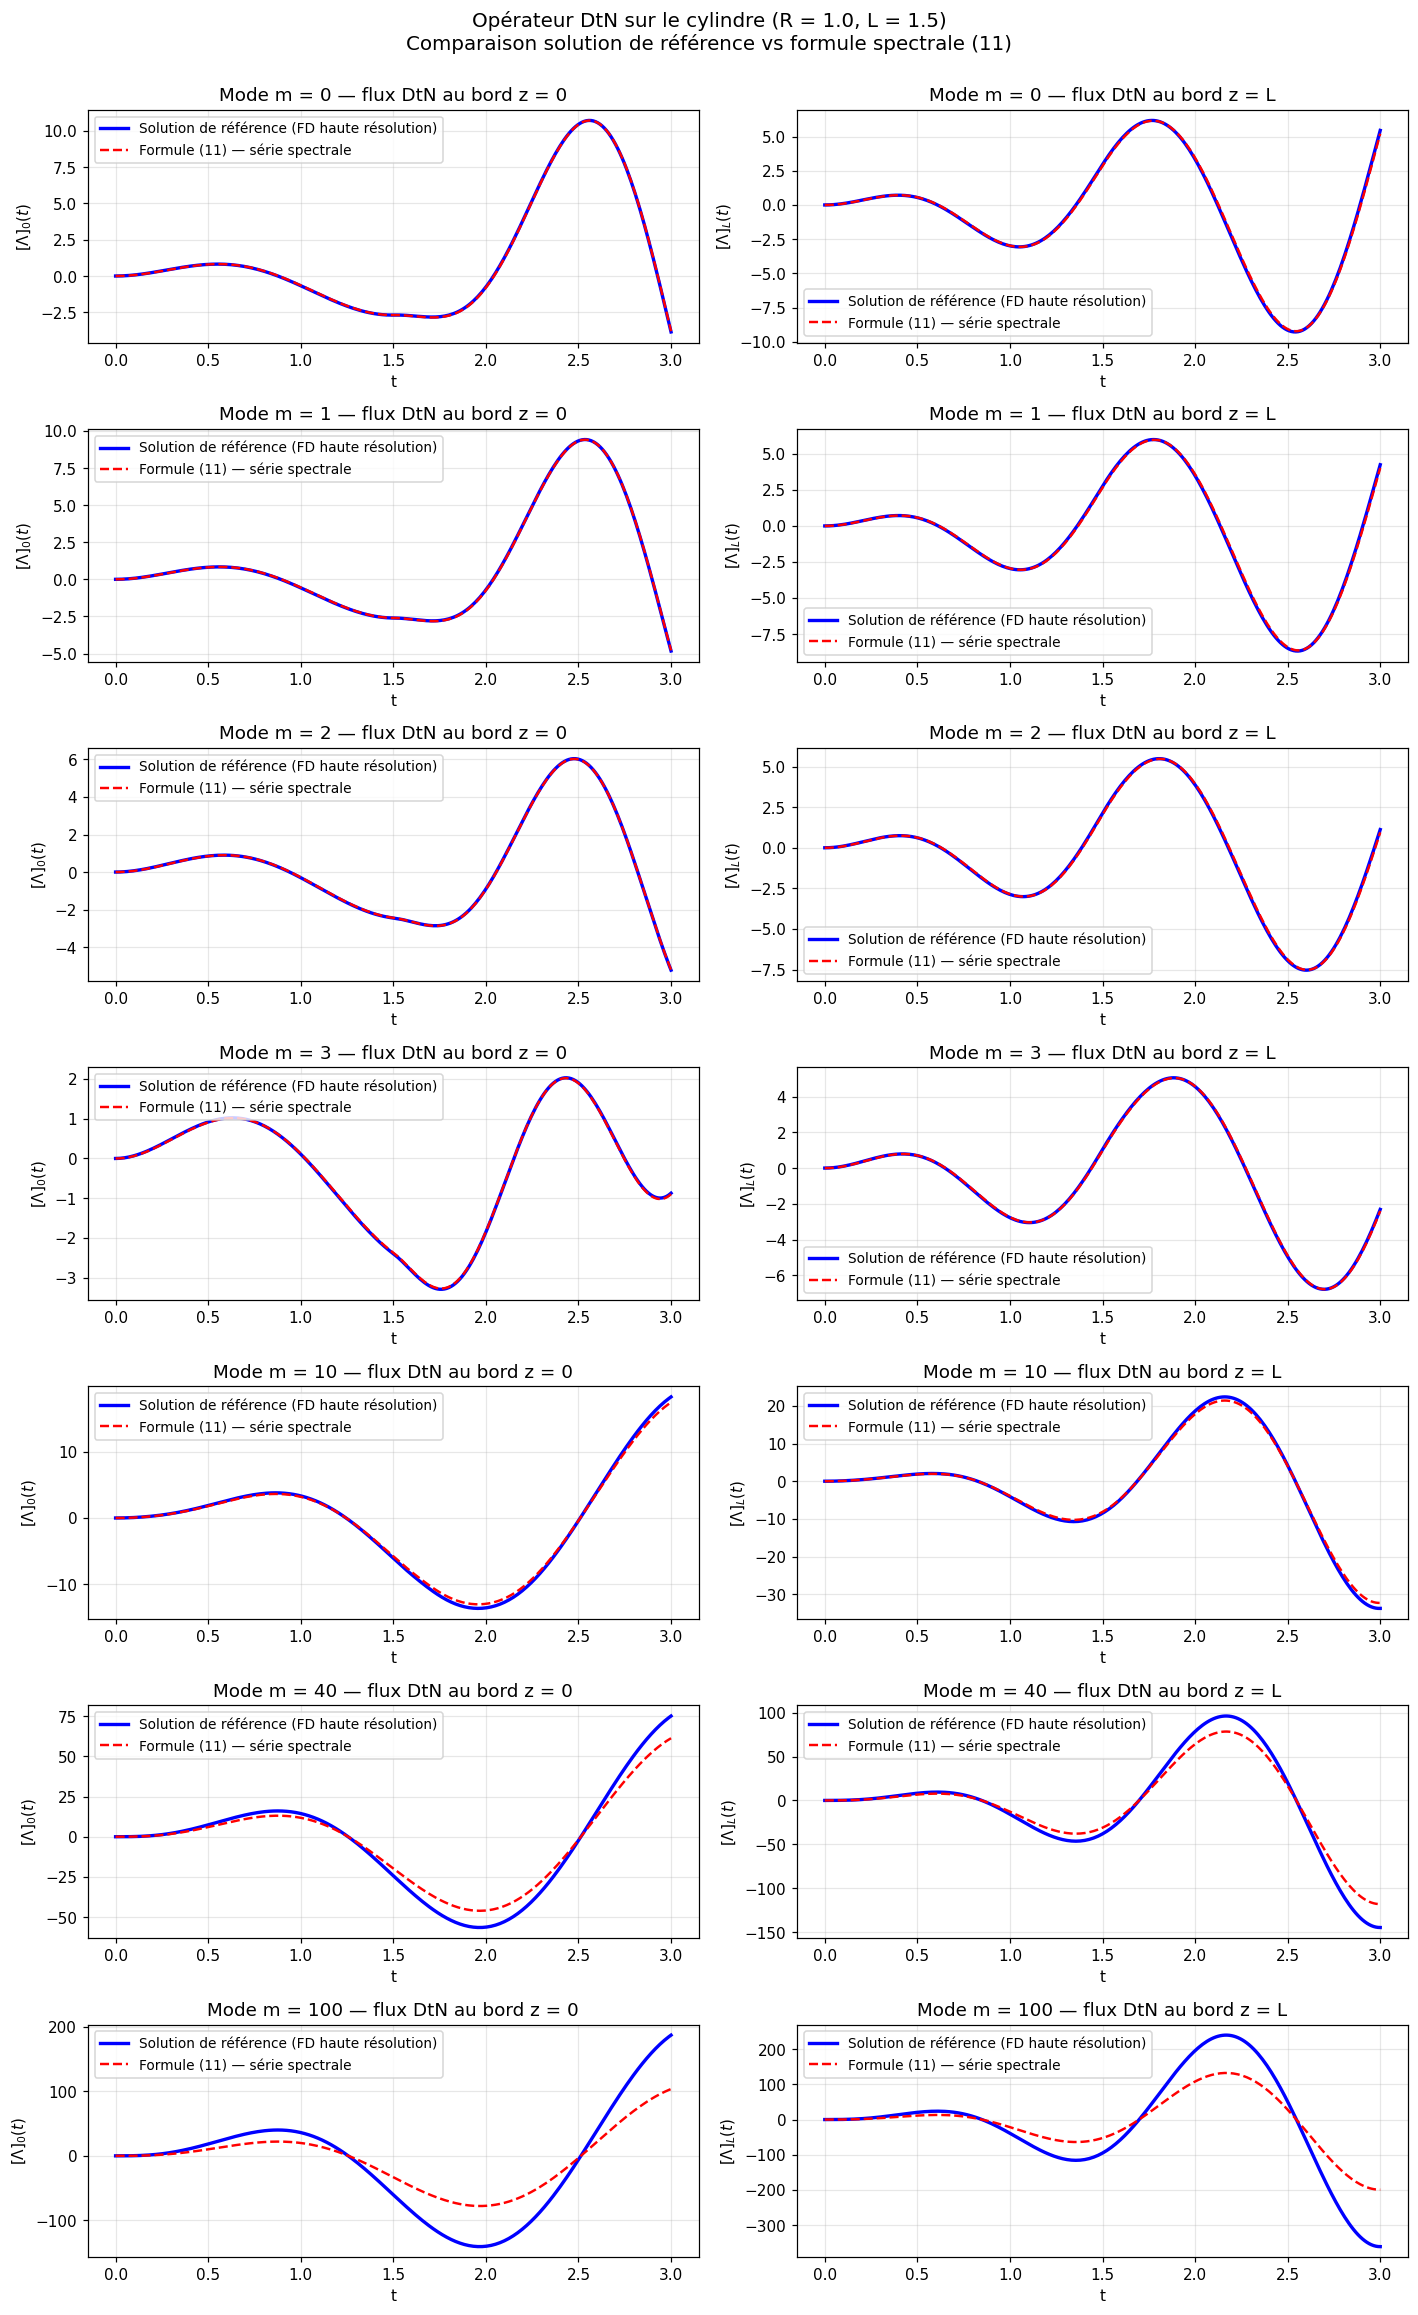

In [6]:
# --- Tracé superposé : une ligne de 2 panneaux (z=0 et z=L) par mode ------
# Objectif : vérifier visuellement que la formule (11) (rouge pointillé)
# se superpose à la solution de référence FD (bleu plein).
fig, axes = plt.subplots(len(modes), 2, figsize=(13, 3 * len(modes)))
for i, res in enumerate(results):
    t = res['t']; m = res['m']

    # --- Bord z = 0 -------------------------------------------------------
    ax = axes[i, 0]
    ax.plot(t, res['flux0_ref'], 'b-', lw=2.2,
            label='Solution de référence (FD haute résolution)')
    ax.plot(t, res['flux0_spec'], 'r--', lw=1.6,
            label='Formule (11) — série spectrale')
    ax.set_title(f'Mode m = {m} — flux DtN au bord z = 0')
    ax.set_xlabel('t'); ax.set_ylabel(r'$[\Lambda]_0(t)$')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

    # --- Bord z = L -------------------------------------------------------
    ax = axes[i, 1]
    ax.plot(t, res['fluxL_ref'], 'b-', lw=2.2,
            label='Solution de référence (FD haute résolution)')
    ax.plot(t, res['fluxL_spec'], 'r--', lw=1.6,
            label='Formule (11) — série spectrale')
    ax.set_title(f'Mode m = {m} — flux DtN au bord z = L')
    ax.set_xlabel('t'); ax.set_ylabel(r'$[\Lambda]_L(t)$')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)

# Titre global de la figure (R et L rappelés).
plt.suptitle(
    f"Opérateur DtN sur le cylindre (R = {R}, L = {L})\n"
    "Comparaison solution de référence vs formule spectrale (11)",
    fontsize=13, y=1.00
)
plt.tight_layout()
plt.show()


### Tableau récapitulatif des erreurs relatives


In [7]:
# --- Tableau récapitulatif des erreurs relatives par mode ----------------
# En-tête formaté (alignement à droite via les spécificateurs ">").
print(f"{'Mode m':>6} | {'err rel z=0':>14} | {'err rel z=L':>14}")
print("-" * 42)
for res in results:
    # On ignore le tout début du signal : le transitoire initial est
    # numériquement bruité et fausserait l'erreur relative.
    skip = len(res['t']) // 20  # on saute les 5 % premiers points

    # Erreur absolue L-infini (écart max) entre référence et formule.
    err0 = np.max(np.abs(res['flux0_ref'][skip:] - res['flux0_spec'][skip:]))
    errL = np.max(np.abs(res['fluxL_ref'][skip:] - res['fluxL_spec'][skip:]))

    # Normalisation par l'amplitude max du signal de référence.
    norm0 = np.max(np.abs(res['flux0_ref'][skip:]))
    normL = np.max(np.abs(res['fluxL_ref'][skip:]))

    # Erreur relative ; le max(., 1e-10) évite une division par ~0
    # (cas m=0 où le flux peut être de très faible amplitude).
    r0 = err0 / max(norm0, 1e-10)
    rL = errL / max(normL, 1e-10)
    print(f"{res['m']:>6} | {r0:>14.3e} | {rL:>14.3e}")


Mode m |    err rel z=0 |    err rel z=L
------------------------------------------
     0 |      4.946e-03 |      2.588e-02
     1 |      4.675e-03 |      2.575e-02
     2 |      3.983e-03 |      2.290e-02
     3 |      7.875e-03 |      1.286e-02
    10 |      4.505e-02 |      4.334e-02
    40 |      1.839e-01 |      1.842e-01
   100 |      4.466e-01 |      4.480e-01


## 5 — Focus sur un mode 

Pour mieux visualiser la qualité de l'accord, on agrandit le cas $m = 2$ et
on trace aussi l'erreur absolue en échelle logarithmique.


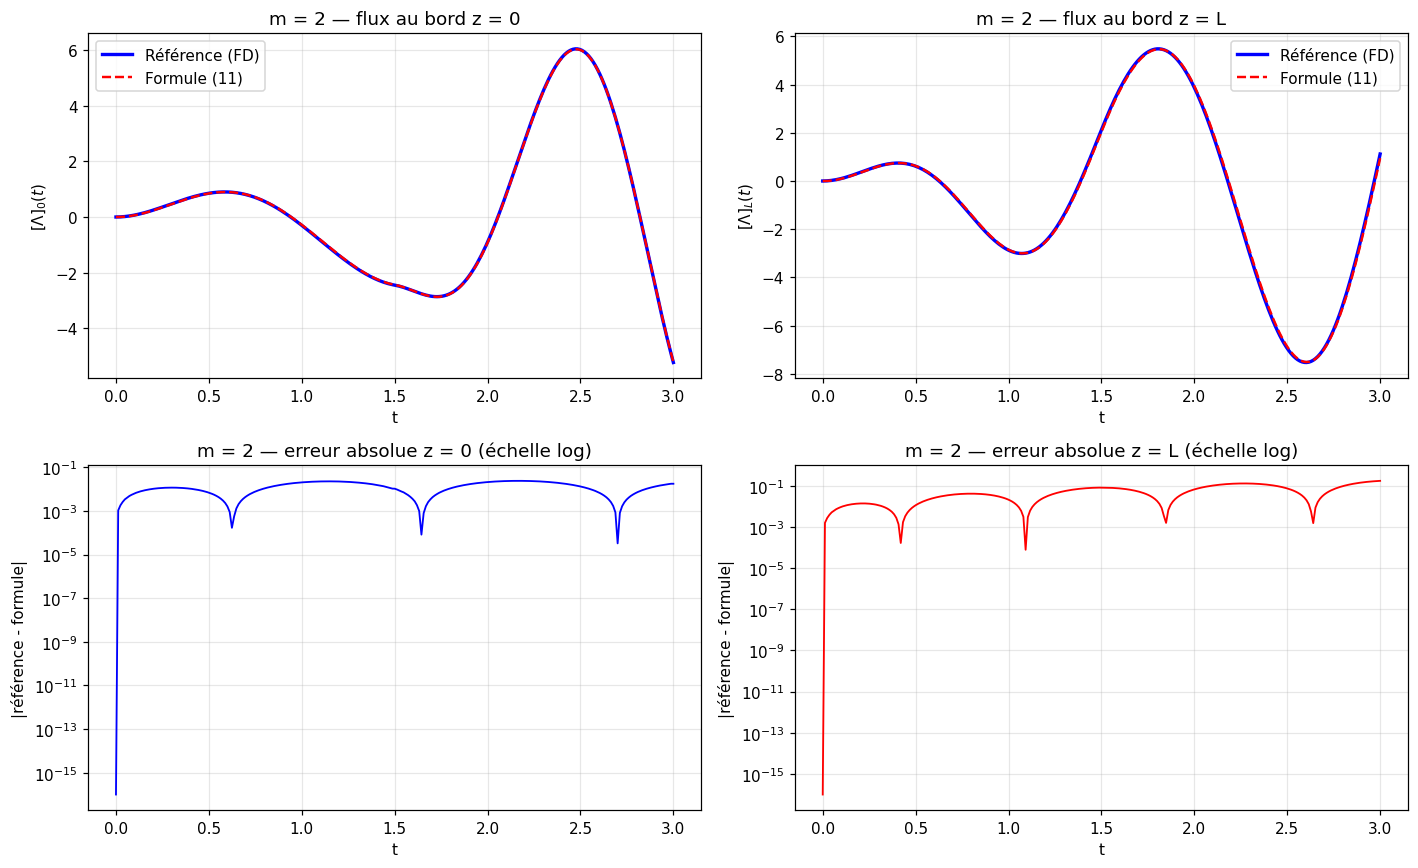

In [8]:
# --- Vue rapprochée sur un mode représentatif (m = 2) --------------------
m_focus = 2
# Récupère le résultat déjà calculé correspondant à ce mode.
res = next(r for r in results if r['m'] == m_focus)
t = res['t']

# Grille 2x2 : flux (haut) puis erreur absolue en échelle log (bas).
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# --- Flux en z = 0 : référence vs formule --------------------------------
ax = axes[0, 0]
ax.plot(t, res['flux0_ref'],  'b-',  lw=2.2, label='Référence (FD)')
ax.plot(t, res['flux0_spec'], 'r--', lw=1.6, label='Formule (11)')
ax.set_title(f'm = {m_focus} — flux au bord z = 0')
ax.set_xlabel('t'); ax.set_ylabel(r'$[\Lambda]_0(t)$')
ax.legend(); ax.grid(True, alpha=0.3)

# --- Flux en z = L : référence vs formule --------------------------------
ax = axes[0, 1]
ax.plot(t, res['fluxL_ref'],  'b-',  lw=2.2, label='Référence (FD)')
ax.plot(t, res['fluxL_spec'], 'r--', lw=1.6, label='Formule (11)')
ax.set_title(f'm = {m_focus} — flux au bord z = L')
ax.set_xlabel('t'); ax.set_ylabel(r'$[\Lambda]_L(t)$')
ax.legend(); ax.grid(True, alpha=0.3)

# --- Erreur absolue en z = 0 (échelle log) -------------------------------
# Le +1e-16 évite log(0) là où l'écart est nul (sécurise l'axe log).
ax = axes[1, 0]
ax.semilogy(t, np.abs(res['flux0_ref'] - res['flux0_spec']) + 1e-16,
            'b-', lw=1.2)
ax.set_title(f'm = {m_focus} — erreur absolue z = 0 (échelle log)')
ax.set_xlabel('t'); ax.set_ylabel('|référence - formule|')
ax.grid(True, alpha=0.3, which='both')

# --- Erreur absolue en z = L (échelle log) -------------------------------
ax = axes[1, 1]
ax.semilogy(t, np.abs(res['fluxL_ref'] - res['fluxL_spec']) + 1e-16,
            'r-', lw=1.2)
ax.set_title(f'm = {m_focus} — erreur absolue z = L (échelle log)')
ax.set_xlabel('t'); ax.set_ylabel('|référence - formule|')
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()


## 6 — Étude de convergence de la formule (11) en fonction de $k_{\max}$

On regarde comment l'erreur décroît avec le nombre de termes de
Mittag-Leffler conservés.


<>:24: SyntaxWarning: invalid escape sequence '\i'
<>:24: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_46/1150125844.py:24: SyntaxWarning: invalid escape sequence '\i'
  ax.set_ylabel('erreur relative $L^\infty$ (bord z=0)')


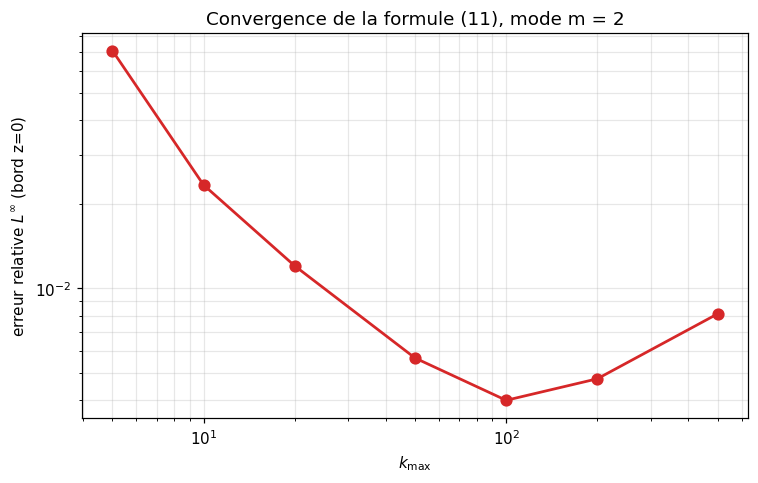


 k_max |    err rel
---------------------
     5 |  7.076e-02
    10 |  2.344e-02
    20 |  1.205e-02
    50 |  5.640e-03
   100 |  3.983e-03
   200 |  4.754e-03
   500 |  8.117e-03


In [9]:
# --- Étude de convergence : erreur en fonction du nombre de modes k_max ---
# On fixe le mode azimutal m=2 et on fait varier la troncature k_max
# de la série spectrale pour observer la décroissance de l'erreur.
m_test = 2
t_fd, flux0_fd, fluxL_fd = solve_wave_cylinder_mode(
    m_test, R, L, f0, fL, T=T, Nz=1000, CFL=0.4)

# Sous-échantillonnage à ~250 points (coût O(Nt²) de la formule).
step = max(1, len(t_fd) // 250)
t_sub = t_fd[::step]
flux0_ref = flux0_fd[::step]

skip = len(t_sub) // 20          # on ignore le transitoire initial (5 %)

# Valeurs de troncature testées (croissance géométrique).
k_list = [5, 10, 20, 50, 100, 200, 500]
errs_0 = []
for K in k_list:
    # Formule (11) recalculée avec K modes axiaux.
    fs0, _ = dtn_spectral_cylinder_mode(
        m_test, R, L, t_sub,
        f0(t_sub), fL(t_sub), f0_dd(t_sub), fL_dd(t_sub),
        k_modes=K)
    # Erreur L-infini absolue puis normalisée -> erreur relative.
    err = np.max(np.abs(flux0_ref[skip:] - fs0[skip:]))
    errs_0.append(err / np.max(np.abs(flux0_ref[skip:])))

# Tracé log-log : sur ce type d'échelle, une pente constante révèle
# l'ordre de convergence de la troncature.
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(k_list, errs_0, 'o-', lw=1.8, color='C3', markersize=7)
ax.set_xlabel(r'$k_{\max}$')
ax.set_ylabel(r'erreur relative $L^\infty$ (bord z=0)')
ax.set_title(f'Convergence de la formule (11), mode m = {m_test}')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

# Récapitulatif chiffré de la convergence.
print(f"\n{'k_max':>6} | {'err rel':>10}")
print("-" * 21)
for K, e in zip(k_list, errs_0):
    print(f"{K:>6} | {e:>10.3e}")


## 7 — Comportement de la formule pour les grands modes azimutaux 

On observe que la formule (11) tronquée à $k_{\max}$ termes perd progressivement
en précision lorsque le mode $m$ augmente : l'erreur relative passe d'environ
$0{,}5\,\%$ pour $m=2$ à $4\,\%$ pour $m=10$, puis à plusieurs dizaines de
pourcents au-delà de $m=40$. Cette section analyse l'origine de cette
dégradation.

### Origine théorique : condensation des fréquences propres

Les fréquences propres du cylindre sont
$$\omega_{m,k}^2 = \left(\frac{k\pi}{L}\right)^2 + \alpha,
\qquad \alpha = \left(\frac{m}{R}\right)^2.$$

Lorsque $m$ devient grand, $\alpha$ écrase le terme axial $(k\pi/L)^2$ pour les
premiers $k$. Toutes les fréquences propres se condensent autour de la valeur
commune $\sqrt{\alpha} = m/R$ :
- pour $m = 0$ : $\omega_{m,k}$ croît linéairement en $k$ (gap relatif 100\,\%) ;
- pour $m = 100$ : $\omega_{m,1}, \omega_{m,2}, \omega_{m,3}, \ldots$ valent
  toutes approximativement $100$ (gap relatif $0{,}07\,\%$).

Concrètement, il faut plus de termes pour échantillonner correctement la
gamme de fréquences pertinente, ce qui se traduit par une convergence beaucoup
plus lente de la série tronquée.

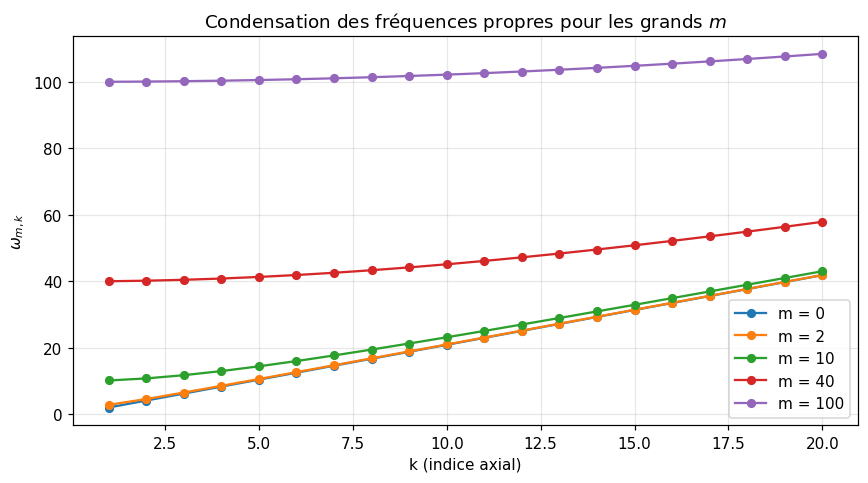

In [10]:
# --- Visualisation de la condensation des fréquences propres -------------
# On trace ω_{m,k} en fonction de k pour différents m. Pour m grand,
# le terme α = (m/R)² écrase (kπ/L)² : les courbes s'aplatissent,
# les fréquences se "condensent" autour de m/R -> convergence lente.
fig, ax = plt.subplots(figsize=(8, 4.5))
ks = np.arange(1, 21)                       # 20 premiers indices axiaux
for m in [0, 2, 10, 40, 100]:
    alpha = (m / R) ** 2
    omegas = np.sqrt((ks * np.pi / L)**2 + alpha)
    ax.plot(ks, omegas, 'o-', label=f'm = {m}', markersize=5)
ax.set_xlabel('k (indice axial)')
ax.set_ylabel(r'$\omega_{m,k}$')
ax.set_title('Condensation des fréquences propres pour les grands $m$')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Mesure quantitative de la dégradation

On mesure l'erreur relative de la formule pour des modes croissants, en
gardant $k_{\max} = 100$ termes. On affiche aussi l'amplitude des flux pour
contextualiser.

In [11]:
def measure_error(m, k_modes=100):
    """Renvoie (e0, eL) : erreurs relatives L-infini de la formule (11)
    par rapport à la référence FD, pour les bords z=0 et z=L, à k_max fixé.
    """
    # Référence FD haute résolution pour ce mode.
    t_fd, flux0_fd, fluxL_fd = solve_wave_cylinder_mode(
        m, R, L, f0, fL, T=T, Nz=1000, CFL=0.4)

    # Sous-échantillonnage (coût quadratique de la formule spectrale).
    step = max(1, len(t_fd) // 250)
    t_sub = t_fd[::step]
    flux0_ref = flux0_fd[::step]
    fluxL_ref = fluxL_fd[::step]

    # Formule (11) sur la même grille.
    flux0_spec, fluxL_spec = dtn_spectral_cylinder_mode(
        m, R, L, t_sub,
        f0(t_sub), fL(t_sub), f0_dd(t_sub), fL_dd(t_sub),
        k_modes=k_modes)

    skip = len(t_sub) // 20      # transitoire initial ignoré (5 %)

    # Erreurs relatives (max(., 1e-10) : garde-fou contre division par ~0).
    e0 = (np.max(np.abs(flux0_ref[skip:] - flux0_spec[skip:]))
          / max(np.max(np.abs(flux0_ref[skip:])), 1e-10))
    eL = (np.max(np.abs(fluxL_ref[skip:] - fluxL_spec[skip:]))
          / max(np.max(np.abs(fluxL_ref[skip:])), 1e-10))
    return e0, eL


# --- Balayage de l'erreur en fonction du mode azimutal m -----------------
modes_test = [0, 1, 2, 3, 5, 10, 20, 40, 70, 100]
errs_0, errs_L = [], []
for m in modes_test:
    e0, eL = measure_error(m)
    errs_0.append(e0); errs_L.append(eL)
    # Affichage en pourcentage (format ">8.2%").
    print(f"m = {m:>3}   err z=0 = {e0:>8.2%}   err z=L = {eL:>8.2%}")


m =   0   err z=0 =    0.49%   err z=L =    2.59%


m =   1   err z=0 =    0.47%   err z=L =    2.57%


m =   2   err z=0 =    0.40%   err z=L =    2.29%


m =   3   err z=0 =    0.79%   err z=L =    1.29%


m =   5   err z=0 =    1.91%   err z=L =    1.61%


m =  10   err z=0 =    4.50%   err z=L =    4.33%


m =  20   err z=0 =    9.21%   err z=L =    9.15%


m =  40   err z=0 =   18.39%   err z=L =   18.42%


m =  70   err z=0 =   31.78%   err z=L =   31.88%


m = 100   err z=0 =   44.66%   err z=L =   44.80%


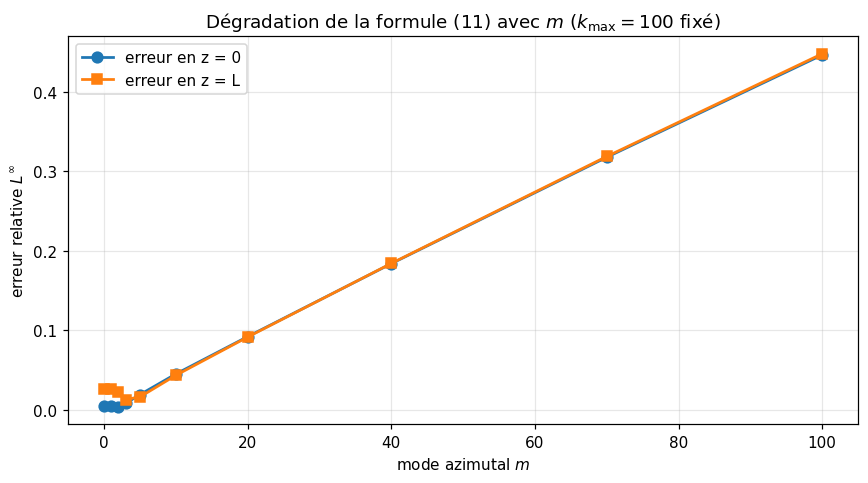

In [12]:
# --- Courbe de l'erreur relative en fonction de m (k_max = 100 fixé) -----
# Met en évidence la dégradation progressive de la formule tronquée
# quand le mode azimutal augmente.
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(modes_test, errs_0, 'o-', label='erreur en z = 0', lw=1.8, markersize=7)
ax.plot(modes_test, errs_L, 's-', label='erreur en z = L', lw=1.8, markersize=7)
ax.set_xlabel('mode azimutal $m$')
ax.set_ylabel(r'erreur relative $L^\infty$')
ax.set_title(r'Dégradation de la formule (11) avec $m$ ($k_{\max} = 100$ fixé)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Vérification : la queue tronquée croît avec $m$

On évalue la queue $\sum_{k > 100} 1/\omega_{m,k}^2$ relativement à la somme
totale. Plus cette fraction est grande, plus la troncature à $k_{\max} = 100$
est insuffisante.

In [13]:
# --- Quantification de la queue de série négligée à k_max = 100 ----------
# On compare la somme "presque complète" (jusqu'à K_huge) à la somme
# tronquée à 100 termes. Le ratio queue/total mesure ce qui manque :
# il explose avec m, ce qui explique la perte de précision.
print(f"{'m':>4} | {'somme totale':>15} | {'queue k>100':>15} | {'queue/total':>12}")
print("-" * 56)
K_huge = 5000                              # troncature "de référence" (quasi-exacte)
for m in [0, 2, 10, 40, 100]:
    alpha = (m / R) ** 2
    # Somme quasi-complète des 1/ω_{m,k}² (proxy du poids spectral total).
    full    = sum(1/((k*np.pi/L)**2 + alpha) for k in range(1, K_huge + 1))
    # Somme tronquée effectivement calculée par la formule (k_max = 100).
    partial = sum(1/((k*np.pi/L)**2 + alpha) for k in range(1, 101))
    tail    = full - partial               # part négligée (queue k > 100)
    print(f"{m:>4} | {full:>15.4e} | {tail:>15.4e} | {tail/full:>11.2%}")


   m |    somme totale |     queue k>100 |  queue/total
--------------------------------------------------------
   0 |      3.7495e-01 |      2.2228e-03 |       0.59%
   2 |      2.5182e-01 |      2.2227e-03 |       0.88%
  10 |      6.9954e-02 |      2.2211e-03 |       3.18%
  40 |      1.8392e-02 |      2.1960e-03 |      11.94%
 100 |      7.4044e-03 |      2.0721e-03 |      27.98%


### Effet d'amplification par le terme $\alpha f$

La source convoluée dans la formule (11) est $g(\tau) = f''(\tau) + \alpha f(\tau)$.
Pour les grands $m$, $\alpha = (m/R)^2$ peut atteindre des valeurs très
supérieures à $|f''|$, et toute erreur sur $g$ est multipliée par cet
amplificateur.

Pour $m = 100$ et notre donnée test, le rapport $|\alpha f| / |f''|$
dépasse $10^4$ : la quadrature trapèze, dont l'erreur sur $g$ est en
$O(\Delta t^2)$, voit son erreur effective multipliée par ce facteur.

### Précision de la solution de référence

Pour les très grands modes, la solution FD elle-même devient moins précise.
Avec $N_z = 1000$, la solution FD pour $m = 100$ n'a une précision spatiale
que de l'ordre de $3\,\%$ (vérifiable en comparant avec $N_z = 4000$). Une
partie de l'écart observé entre référence et formule provient donc d'une
inexactitude de la référence elle-même, pas seulement de la formule.

In [14]:
# --- Test de convergence de la RÉFÉRENCE FD elle-même (m = 100) ----------
# On raffine la grille spatiale Nz et on regarde le flux à un instant fixe
# (t = 1.5). Si la valeur ne se stabilise pas, c'est que la "référence"
# n'est pas convergée : une partie de l'écart observé lui est imputable.
print("Convergence de la solution FD pour m = 100 (flux en z=0 à t=1.5) :")
print(f"{'Nz':>6} | {'flux0(t=1.5)':>14}")
print("-" * 25)
for Nz in [500, 1000, 2000, 4000]:
    t_fd, flux0_fd, _ = solve_wave_cylinder_mode(100, R, L, f0, fL, T=T, Nz=Nz, CFL=0.4)
    # Indice du pas de temps le plus proche de t = 1.5.
    idx = int(1.5 / (T / len(flux0_fd)))
    print(f"{Nz:>6} | {flux0_fd[idx]:>14.4f}")
print()
print("La valeur n'est pas stabilisée : la 'référence' a elle-même environ 3% d'erreur.")


Convergence de la solution FD pour m = 100 (flux en z=0 à t=1.5) :
    Nz |   flux0(t=1.5)
-------------------------
   500 |       -59.0711


  1000 |       -60.2821


  2000 |       -60.6237


  4000 |       -60.7143

La valeur n'est pas stabilisée : la 'référence' a elle-même environ 3% d'erreur.


### Pourquoi la solution FD se dégrade-t-elle avec $m$ ?

Le schéma centré ne résout pas l'équation des ondes pure mais l'**équation
de Klein-Gordon**

$$\partial_t^2 u - \partial_z^2 u + \alpha\,u = 0,
\qquad \alpha = (m/R)^2,$$

dont le terme de masse $\alpha u$ change qualitativement le comportement et
la précision atteignable.

**1. Erreur sur la fréquence propre.** En injectant une onde plane
$u = e^{i(kz - \omega t)}$, l'équation continue donne la relation de
dispersion exacte $\omega^2 = k^2 + \alpha$. Le schéma centré, lui, vérifie
une relation discrète

$$\frac{4}{\Delta t^2}\sin^2\!\left(\frac{\omega \Delta t}{2}\right)
= \frac{4}{\Delta z^2}\sin^2\!\left(\frac{k \Delta z}{2}\right) + \alpha,$$

qui coïncide avec la relation continue à $O(\Delta t^2 + \Delta z^2)$. Pour
$k = \pi/L$ fixé, l'erreur effective sur $\omega$ est :

| $m$ | $\omega$ exact | $\omega$ schéma | erreur |
|-----|---------------|-----------------|--------|
| 0   | 2,09          | 2,09            | $7 \times 10^{-7}$ |
| 10  | 10,22         | 10,22           | $1{,}6 \times 10^{-5}$ |
| 40  | 40,05         | 40,06           | $9{,}6 \times 10^{-4}$ |
| 100 | 100,02        | 100,04          | $1{,}5 \times 10^{-2}$ |

L'erreur croît rapidement avec $m$. Comme $u$ oscille à $\omega$, l'erreur
de phase accumulée après un temps $T$ vaut $\Delta\omega \cdot T$, soit
environ $5\,\%$ de décalage pour $m = 100$ et $T = 3$.

**2. Raideur du problème.** La vitesse de phase de Klein-Gordon

$$v_\text{phase} = \frac{\omega}{k} = \sqrt{1 + \frac{\alpha}{k^2}}$$

devient très grande pour $\alpha$ grand et $k$ modéré : $v_\text{phase}
\approx 48$ pour $m = 100$ et $k = \pi/L$. Les modes spatialement lents
oscillent alors $48$ fois plus vite en temps qu'en espace, ce qui crée une
séparation d'échelles caractéristique d'un problème **raide**.

**3. Nombre de points par période.** Pour résoudre numériquement des
oscillations à la pulsation $\omega \sim m/R$, on souhaite $\Delta t \ll R/m$.
Avec $\Delta t = 0{,}4\,\Delta z = 6 \times 10^{-4}$ et $m = 100$, on a
seulement $\sim 100$ pas de temps par période d'oscillation : suffisant pour
la stabilité, insuffisant pour une grande précision. La CFL classique
$\Delta t \sim \Delta z$ est dérivée pour l'équation des ondes pure
($v_\text{phase} = 1$) et n'est pas adaptée à la dynamique rapide induite
par le terme de masse.

En résumé, la dégradation de la FD pour $m$ grand n'est pas un défaut de
l'implémentation mais une manifestation discrète d'un fait continu : pour
suivre des oscillations à fréquence $\omega \sim m/R$, il faut une grille
temporelle de plus en plus fine, ce qui coûte d'autant plus cher.

### Synthèse et portée pratique

Trois mécanismes combinés expliquent la dégradation aux grands $m$ :

1. **Condensation des fréquences propres** : pour $m$ grand, les
   $\omega_{m,k}$ s'accumulent autour de $m/R$, ralentissant la convergence
   de la série spectrale.
2. **Amplification par $\alpha$** : le préfacteur $\alpha = (m/R)^2$ amplifie
   les erreurs de quadrature sur la source $f'' + \alpha f$.
3. **Limite de la référence FD** : la précision de la solution FD diminue
   pour les grands $m$, ce qui contamine la mesure d'erreur.

**Portée pratique.** En pratique, la décomposition de Fourier d'une donnée
régulière voit ses coefficients $f_m$ décroître rapidement avec $|m|$
(typiquement comme $|m|^{-p}$ pour une donnée $C^p$). Les grands modes
contribuent peu à la solution physique. La formule (11) est donc d'autant
plus fiable que les modes dominants sont les modes basses fréquences, là
où elle est précise. Pour traiter rigoureusement les très grands modes, il
faudrait soit ajuster $k_{\max}$ à $m$ (par exemple $k_{\max} \sim Cm$),
soit utiliser une quadrature mieux adaptée aux noyaux fortement
oscillants.

## 8 — Conclusion

Les deux courbes (solution de référence et formule spectrale 11) se
**superposent visuellement** sur les tracés ci-dessus, avec des erreurs
relatives de l'ordre du pourcent — ce qui est la précision attendue pour
une formule spectrale tronquée à $k_{\max} \sim 100$ termes confrontée à
une solution FD d'ordre 2.

Ce bon accord valide :

- la **décomposition de Mittag-Leffler** de $\mu_m \coth(\mu_m L)$ et
  $\mu_m/\sinh(\mu_m L)$ ;
- l'**astuce du transfert de dérivée** qui convertit chaque terme spectral
  en une convolution temporelle absolument convergente ;
- l'identification correcte des **fréquences propres**
  $\omega_{m,k}^2 = (k\pi/L)^2 + (m/R)^2$ ;
- la **structure matricielle** du symbole (signe alterné $(-1)^k$ dans le
  hors-diagonal) qui encode le couplage entre les deux bords.

La donnée asymétrique ($f_0 \neq f_L$) est essentielle pour cette validation :
elle force tous les termes du tenseur à intervenir non trivialement dans
chaque flux de sortie.
